# Breast Cancer Detection (BreaKHis 400x)

## Env set up

In [30]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

# For radiomics features
from skimage.color import rgb2gray, rgb2hsv
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.exposure import rescale_intensity

## Random Seed Setup

In [31]:
import random

# 设置随机种子为666，确保结果可复现
SEED = 666

# Python随机种子
random.seed(SEED)

# NumPy随机种子
np.random.seed(SEED)

# PyTorch随机种子
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # 如果使用多GPU

# 设置PyTorch的确定性模式（可能会降低性能，但保证可复现）
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 设置Python的hash随机化（可选，用于某些库的确定性）
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"✅ Random seed set to {SEED} for reproducibility")

✅ Random seed set to 666 for reproducibility


## Device setup

In [32]:
device = (
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: mps


## Data loading and preprocessing

In [33]:
class BreastCancerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.img_paths = []
        self.labels = []
        self.classes = [
            c for c in sorted(os.listdir(root_dir))
            if os.path.isdir(os.path.join(root_dir, c)) and not c.startswith('.')
        ]
        for i, c in enumerate(self.classes):
            imgs = glob(os.path.join(root_dir, c, "*.png"))
            self.img_paths.extend(imgs)
            self.labels.extend([i]*len(imgs))
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

class AugmentedBreastCancerDataset(Dataset):
    """
    支持离线数据增强的数据集类
    预先生成增强后的数据副本，真正增加数据集大小
    """
    def __init__(self, root_dir, transform=None, augment_times=1, augment_transforms=None):
        """
        root_dir: 图像根目录
        transform: 测试/验证时的固定变换（不用于增强）
        augment_times: 每个原始图像生成多少个增强副本（0表示不增强，只使用原始数据）
        augment_transforms: 用于增强的变换列表（如果为None，使用默认增强）
        """
        self.img_paths = []
        self.labels = []
        self.classes = [
            c for c in sorted(os.listdir(root_dir))
            if os.path.isdir(os.path.join(root_dir, c)) and not c.startswith('.')
        ]
                
        # 收集原始数据
        for i, c in enumerate(self.classes):
            imgs = glob(os.path.join(root_dir, c, "*.png"))
            self.img_paths.extend(imgs)
            self.labels.extend([i]*len(imgs))
        
        self.transform = transform  # 用于测试/验证的固定变换
        self.augment_times = augment_times
        
        # 默认增强策略（返回numpy格式，便于存储）
        if augment_transforms is None:
            self.augment_transforms = [
                lambda img: cv2.flip(img, 1),  # 水平翻转
                lambda img: cv2.flip(img, 0),  # 垂直翻转
                lambda img: cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE),  # 旋转90度
                lambda img: cv2.rotate(img, cv2.ROTATE_180),  # 旋转180度
                lambda img: cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE),  # 旋转270度
            ]
        else:
            self.augment_transforms = augment_transforms
        
        # 如果augment_times > 0，预先加载并增强数据
        if augment_times > 0:
            print(f"🔄 Pre-generating {augment_times} augmented copies per image...")
            self.augmented_data = []
            self.augmented_labels = []
            
            for idx in tqdm(range(len(self.img_paths)), desc="Augmenting images"):
                # 加载原始图像
                img = cv2.imread(self.img_paths[idx])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                label = self.labels[idx]
                
                # 添加原始图像（总是包含）
                self.augmented_data.append(img.copy())
                self.augmented_labels.append(label)
                
                # 生成增强副本
                for aug_idx in range(min(augment_times, len(self.augment_transforms))):
                    aug_func = self.augment_transforms[aug_idx % len(self.augment_transforms)]
                    try:
                        aug_img = aug_func(img.copy())  # 对副本进行增强
                        self.augmented_data.append(aug_img.copy())
                        self.augmented_labels.append(label)
                    except Exception as e:
                        print(f"Warning: Augmentation failed for {self.img_paths[idx]}: {e}")
                        # 如果增强失败，使用原图
                        self.augmented_data.append(img.copy())
                        self.augmented_labels.append(label)
            
            print(f"✅ Generated {len(self.augmented_data)} samples (original: {len(self.img_paths)})")
            print(f"   Dataset size increased by {len(self.augmented_data) / len(self.img_paths):.1f}x")
            self.use_augmented = True
        else:
            self.use_augmented = False

    def __len__(self):
        if self.use_augmented:
            return len(self.augmented_data)
        return len(self.img_paths)

    def __getitem__(self, idx):
        if self.use_augmented:
            img = self.augmented_data[idx].copy()  # 确保是副本，避免修改原始数据
            label = self.augmented_labels[idx]
        else:
            img = cv2.imread(self.img_paths[idx])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            label = self.labels[idx]
        
        if self.transform:
            # transform期望输入是numpy数组（H, W, C）或PIL Image
            img = self.transform(img)
        
        return img, label

## Model Definitions

In [34]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128*28*28, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class VGGInspired(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*28*28, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

class ResNet18Empty(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(weights=None)
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class ResNet18Freeze(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        for param in base.parameters():
            param.requires_grad = False
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class ResNet18_PT_FT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class ResNet34_PT_FT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class ResNet50_PT_FT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class ResNet50Freeze(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        for param in base.parameters():
            param.requires_grad = False
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class ResNet50Empty(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet50(weights=None)
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class ResNet101_PT_FT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)
    

class DenseNet121_PT_FT(nn.Module):
    """Fine-tuned DenseNet121 with pretrained weights."""
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        base.classifier = nn.Linear(base.classifier.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class DenseNet201_PT_FT(nn.Module):
    """Fine-tuned DenseNet201 with pretrained weights."""
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)
        base.classifier = nn.Linear(base.classifier.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class MobileNetV2_PT_FT(nn.Module):
    """Fine-tuned MobileNetV2 with pretrained weights."""
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        base.classifier[1] = nn.Linear(base.classifier[1].in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class EfficientNetB0_PT_FT(nn.Module):
    """Fine-tuned EfficientNetB0 with pretrained weights."""
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        base.classifier[1] = nn.Linear(base.classifier[1].in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class SimpleMLP(nn.Module):
    """A simple multilayer perceptron for comparison (expects flat input)."""
    def __init__(self, input_dim=3*224*224, num_classes=2):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.layers(x)

## Train code

In [35]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4, class_weights=None, weight_decay=1e-4):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # 使用类别权重处理不平衡问题
    if class_weights is not None:
        class_weights = class_weights.to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()
    
    # 学习率调度器
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.1, patience=3
    )

    train_losses, val_losses = [], []
    train_accs = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        train_correct = 0
        train_total = 0
        
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
            # 计算训练准确率
            train_correct += (out.argmax(1) == labels).sum().item()
            train_total += labels.size(0)
        
        train_losses.append(total_loss / len(train_loader))
        train_acc = train_correct / train_total
        train_accs.append(train_acc)

        # Validation
        model.eval()
        val_loss, correct = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                val_loss += criterion(out, labels).item()
                correct += (out.argmax(1) == labels).sum().item()
        val_acc = correct / len(val_loader.dataset)
        val_losses.append(val_loss / len(val_loader))
        
        # 更新学习率
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_losses[-1])
        new_lr = optimizer.param_groups[0]['lr']
        
        lr_info = f" | LR: {new_lr:.2e}"
        if new_lr < old_lr:
            lr_info += " ⬇️"
        
        print(f"Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc:.4f}{lr_info}")
    
    return train_losses, val_losses, train_accs

## Test code

In [36]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, recall_score, f1_score, accuracy_score

def evaluate_on_testset(model, test_loader, dataset, model_name=None, epoch=None, save=True, save_dir=".", save_suffix=""):
    """
    save_suffix: 目录名后缀，例如 "A" 表示使用离线增强
    """
    model.to(device)
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc="Evaluating"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate metrics
    acc = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average="macro")
    f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"\n✅ Test Accuracy: {acc:.4f}")
    print("\n📊 Classification Report:")
    class_report_str = classification_report(all_labels, all_preds, target_names=dataset.classes)
    print(class_report_str)

    # 保存分类报告到txt文件
    if save and model_name is not None and epoch is not None:
        save_path = os.path.join(save_dir, f"New_{model_name}_{epoch}{save_suffix}")
        os.makedirs(save_path, exist_ok=True)
        report_path = os.path.join(save_path, "classification_report.txt")
        with open(report_path, "w", encoding="utf-8") as f:
            f.write(f"Test accuracy: {acc:.4f}\n\n")
            f.write("Classification Report (macro averaging):\n")
            f.write(class_report_str)
        print(f"✅ Saved classification report to {report_path}")

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.title("Confusion Matrix on Test Set", fontsize=15)

    # 美化坐标轴字体
    ax.tick_params(axis='both', labelsize=10)

    # === 新增：在右下角绘制指标框 === #
    metrics_text = (
        f"Accuracy: {acc:.4f}\n"
        f"Recall:   {recall:.4f}\n"
        f"F1-score: {f1:.4f}\n"
        "(macro average)"
    )

    # 添加文本框
    ax.text(
        1.35, 0.05, metrics_text,
        transform=ax.transAxes,
        fontsize=11,
        va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", fc="#003366", ec="none", alpha=0.85),
        color="white",
    )

    plt.tight_layout()

    if save and model_name is not None and epoch is not None:
        out_path = os.path.join(save_path, "confusion_matrix.pdf")
        plt.savefig(out_path, format="pdf", bbox_inches="tight")
        print(f"✅ Saved confusion matrix to {out_path}")
    elif not save:
        print("⚠️ Skipped saving confusion matrix (save=False)")

    plt.show()
    plt.close()

## Grad-CAM

In [37]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.target_layer = target_layer
        self.hook()

    def hook(self):
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]
        def forward_hook(module, input, output):
            self.feature_map = output
        layer = dict(self.model.named_modules())[self.target_layer]
        layer.register_forward_hook(forward_hook)
        layer.register_backward_hook(backward_hook)

    def generate(self, input_img, class_idx=None):
        self.model.zero_grad()
        out = self.model(input_img)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        score = out[:, class_idx]
        score.backward()
        grads = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = (grads * self.feature_map).sum(dim=1).squeeze()
        cam = F.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        cam = cam.cpu().detach().numpy()
        return cam

def denormalize(img_tensor, mean, std):
    """反标准化函数，用于可视化"""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img_tensor * std + mean

def show_gradcam(img_tensor, cam, mean=None, std=None):
    if mean is not None and std is not None:
        img_vis = denormalize(img_tensor, mean, std)
        img = img_vis.permute(1, 2, 0).cpu().numpy()
        img = np.clip(img, 0, 1)
    else:
        img = img_tensor.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min())

    if cam.ndim > 2:
        cam = cam[0]

    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    overlay = 0.5 * heatmap + 0.5 * img
    overlay = np.clip(overlay, 0, 1)

    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

def show_gradcam_side_by_side(img_tensor, cam, model, dataset, label_true, mean=None, std=None):
    """
    显示原图与 Grad-CAM 热力图并排，并在标题标注预测与真实标签
    """
    model.eval()
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(device))
        pred_idx = output.argmax(1).item()
    pred_label = dataset.classes[pred_idx]
    true_label = dataset.classes[label_true]

    if mean is not None and std is not None:
        img_vis = denormalize(img_tensor, mean, std)
        img = img_vis.permute(1, 2, 0).cpu().numpy()
        img = np.clip(img, 0, 1)
    else:
        img = img_tensor.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min())

    if cam.ndim > 2:
        cam = cam[0]
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    color = "green" if pred_label == true_label else "red"

    axes[0].imshow(img)
    axes[0].set_title("Original", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(heatmap)
    axes[1].set_title("Grad-CAM", fontsize=12)
    axes[1].axis("off")

    fig.suptitle(f"Predicted: {pred_label} | True: {true_label}",
                 color=color, fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()


## Visualization

In [38]:
def plot_curves(train_losses, val_losses, model_name=None, epoch=None, save=True, save_dir=".", save_suffix=""):
    """
    save_suffix: 目录名后缀，例如 "A" 表示使用离线增强
    """
    plt.figure(figsize=(8, 6))
    epochs = np.arange(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label='Training Loss', color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='s', markersize=4)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Training and Validation Loss Curves', fontsize=16, pad=12, weight='bold')
    plt.legend(loc='best', fontsize=12, frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()

    if save and model_name is not None and epoch is not None:
        save_path = os.path.join(save_dir, f"New_{model_name}_{epoch}{save_suffix}")
        os.makedirs(save_path, exist_ok=True)
        out_path = f"{save_path}/loss_curves.pdf"
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        print(f"✅ Saved loss curve to {out_path}")
    elif not save:
        print("⚠️ Skipped saving loss curve (save=False)")

    plt.show()
    plt.close()



def visualize_predictions(model, dataset, num_images=9, mean=None, std=None):
    """
    可视化预测结果
    mean, std: 用于反标准化的均值和标准差（如果提供，会显示正常颜色的图片）
    """
    model.eval()
    indices = np.random.choice(len(dataset), num_images, replace=False)
    n_cols = int(np.ceil(np.sqrt(num_images)))
    n_rows = int(np.ceil(num_images / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.3 * n_cols, 3.3 * n_rows))
    axes = axes.flatten() if num_images > 1 else [axes]

    for ax in axes[num_images:]:
        ax.axis('off')

    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        with torch.no_grad():
            output = model(img.unsqueeze(0).to(device))
            pred = output.argmax(1).item()
        
        # 反标准化以显示正常颜色
        if mean is not None and std is not None:
            img_vis = denormalize(img, mean, std)
            img_np = np.transpose(img_vis.cpu().numpy(), (1, 2, 0))
            img_np = np.clip(img_np, 0, 1)  # 防止越界
        else:
            img_np = np.transpose(img.cpu().numpy(), (1, 2, 0))
            img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

        axes[i].imshow(img_np)
        # Academic professional: show class with full name, pred/true, color highlight for mistakes.
        color = "forestgreen" if pred == label else "crimson"
        axes[i].set_title(
            f"Pred: {dataset.classes[pred]}\nTrue: {dataset.classes[label]}",
            fontsize=11,
            color=color,
            fontweight='bold',
            loc='center'
        )
        axes[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        axes[i].spines['top'].set_color(color)
        axes[i].spines['right'].set_color(color)
        axes[i].spines['left'].set_color(color)
        axes[i].spines['bottom'].set_color(color)
        axes[i].spines['top'].set_linewidth(2 if pred != label else 1)
        axes[i].spines['right'].set_linewidth(2 if pred != label else 1)
        axes[i].spines['left'].set_linewidth(2 if pred != label else 1)
        axes[i].spines['bottom'].set_linewidth(2 if pred != label else 1)
        axes[i].set_xticks([])
        axes[i].set_yticks([])

    plt.suptitle("Model Predictions vs Ground Truth", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## Pipeline

### Model selection

In [39]:
model_name = 'DenseNet201_PT_FT'  

if model_name == 'SimpleCNN':
    model = SimpleCNN()
elif model_name == 'VGGInspired':
    model = VGGInspired()
elif model_name == 'ResNet18Empty':
    model = ResNet18Empty()
elif model_name == 'ResNet18_PT_FT':
    model = ResNet18_PT_FT()
elif model_name == 'ResNet34_PT_FT':
    model = ResNet34_PT_FT()
elif model_name == 'ResNet50_PT_FT':
    model = ResNet50_PT_FT()
elif model_name == 'ResNet101_PT_FT':
    model = ResNet101_PT_FT()
elif model_name == 'ResNet18Freeze':
    model = ResNet18Freeze()
elif model_name == 'DenseNet121_PT_FT':
    model = DenseNet121_PT_FT()
elif model_name == 'DenseNet201_PT_FT':
    model = DenseNet201_PT_FT()
elif model_name == 'MobileNetV2_PT_FT':
    model = MobileNetV2_PT_FT()
elif model_name == 'EfficientNetB0_PT_FT':
    model = EfficientNetB0_PT_FT()
elif model_name == 'SimpleMLP':
    model = SimpleMLP()
else:
    raise ValueError(f"Unknown model_name: {model_name}")

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /Users/carrot/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:10<00:00, 7.45MB/s]


### Preprocessing

In [40]:
data_dir = "./BreaKHis_400X"

# ===== 数据增强策略选择 ===== #
# 方法1: 在线数据增强（Online Augmentation）- 当前标准方法
# 优点：不占用额外内存，每个epoch看到不同的增强版本
# 缺点：数据集大小不变，只是每次看到的版本不同
USE_OFFLINE_AUGMENTATION = False  # 设置为 True 使用离线增强

# ===== 统一使用 ImageNet 归一化 ===== #
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

mean_used = IMAGENET_MEAN
std_used = IMAGENET_STD

print("✅ Using ImageNet normalization for all models")
print("Mean:", mean_used)
print("Std:", std_used)

if USE_OFFLINE_AUGMENTATION:
    print("\n📦 Using OFFLINE augmentation (pre-generating augmented copies)")
    print("   This will increase dataset size by creating augmented copies")
    
    # 定义用于预生成的增强变换（使用OpenCV函数，返回numpy数组）
    augment_transforms = [
        lambda img: cv2.flip(img, 1),  # 水平翻转
        lambda img: cv2.flip(img, 0),  # 垂直翻转
        lambda img: cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE),  # 旋转90度
        lambda img: cv2.rotate(img, cv2.ROTATE_180),  # 旋转180度
    ]
    
    # 训练时的最终变换（包含resize、normalize等）
    train_tfms = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 可以再加一层随机裁剪
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean_used, std=std_used),
    ])
    
    # 使用离线增强数据集（每个原始图像生成3个增强副本）
    full_train_ds = AugmentedBreastCancerDataset(
        os.path.join(data_dir, "train"), 
        transform=train_tfms,
        augment_times=3,  # 每个原始图像生成3个增强副本（加上原图共4个）
        augment_transforms=augment_transforms
    )
else:
    print("\n🔄 Using ONLINE augmentation (standard method)")
    print("   Augmentation applied randomly during training")
    
    # 在线增强：每次读取时随机应用变换
    train_tfms = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean_used, std=std_used),
    ])
    
    full_train_ds = BreastCancerDataset(os.path.join(data_dir, "train"), train_tfms)

# 测试集不使用增强
test_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_used, std=std_used),
])
test_ds = BreastCancerDataset(os.path.join(data_dir, "test"), test_tfms)

# 划分验证集
val_ratio = 0.2
val_size = int(len(full_train_ds) * val_ratio)
train_size = len(full_train_ds) - val_size
train_ds, val_ds = random_split(
    full_train_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)
test_loader = DataLoader(test_ds, batch_size=16)

# ===== 计算类别权重（处理不平衡问题） ===== #
# 统计训练集中的类别分布
num_classes = len(full_train_ds.classes) if hasattr(full_train_ds, "classes") else 2
class_counts = torch.zeros(num_classes)
if isinstance(train_ds, torch.utils.data.Subset):
    for idx in train_ds.indices:
        _, label = full_train_ds[idx]
        class_counts[label] += 1
else:
    # 若不是 subset，保持原方法
    for _, label in train_ds:
        class_counts[label] += 1

# 计算权重：样本数越少，权重越大
class_weights = 1.0 / (class_counts + 1e-6)  # 避免除零
class_weights = class_weights / class_weights.sum() * len(class_weights)  # 归一化

print(f"\n📊 Class distribution in training set:")
for i, class_name in enumerate(full_train_ds.classes):
    print(f"  {class_name}: {int(class_counts[i])} samples")
print(f"\n⚖️  Class weights: {class_weights.tolist()}")
print(f"📦 Total training samples: {len(train_ds)} (original: {len(full_train_ds.img_paths) if hasattr(full_train_ds, 'img_paths') else 'N/A'})")

# ===== 设置模型保存目录后缀 ===== #
# 如果使用离线增强，在目录名后加"A"（Augmentation）
save_suffix = "A" if USE_OFFLINE_AUGMENTATION else ""
print(f"💾 Model save suffix: '{save_suffix}' (will be appended to directory name)")

✅ Using ImageNet normalization for all models
Mean: [0.485, 0.456, 0.406]
Std: [0.229, 0.224, 0.225]

🔄 Using ONLINE augmentation (standard method)
   Augmentation applied randomly during training

📊 Class distribution in training set:
  benign: 330 samples
  malignant: 682 samples

⚖️  Class weights: [1.3478261232376099, 0.6521739363670349]
📦 Total training samples: 1012 (original: 1264)
💾 Model save suffix: '' (will be appended to directory name)


### Start training

In [41]:
epoch = 30  # 增加训练轮数
train_losses = []
val_losses = []
train_accs = []

# 训练模型，使用类别权重和 weight_decay
train_losses, val_losses, train_accs = train_model(
    model, 
    train_loader, 
    val_loader, 
    epochs=epoch,           
    lr=1e-4,
    class_weights=class_weights,
    weight_decay=1e-4
)

Epoch 1/30: 100%|██████████| 64/64 [00:56<00:00,  1.13it/s]


Epoch 1 | Train Loss: 0.2918 | Train Acc: 0.8785 | Val Loss: 0.1576 | Val Acc: 0.9405 | LR: 1.00e-04


Epoch 2/30: 100%|██████████| 64/64 [00:53<00:00,  1.19it/s]


Epoch 2 | Train Loss: 0.1392 | Train Acc: 0.9437 | Val Loss: 0.1619 | Val Acc: 0.9087 | LR: 1.00e-04


Epoch 3/30: 100%|██████████| 64/64 [00:59<00:00,  1.07it/s]


...

Epoch 28 | Train Loss: 0.0047 | Train Acc: 0.9990 | Val Loss: 0.1177 | Val Acc: 0.9802 | LR: 1.00e-08


Epoch 29/30: 100%|██████████| 64/64 [01:21<00:00,  1.28s/it]


Epoch 29 | Train Loss: 0.0036 | Train Acc: 1.0000 | Val Loss: 0.1085 | Val Acc: 0.9802 | LR: 1.00e-08


Epoch 30/30: 100%|██████████| 64/64 [01:23<00:00,  1.30s/it]


Epoch 30 | Train Loss: 0.0042 | Train Acc: 1.0000 | Val Loss: 0.0983 | Val Acc: 0.9762 | LR: 1.00e-08


In [42]:
# 使用后缀（如果使用离线增强，目录名会加上"A"）
save_dir_name = f"New_{model_name}_{epoch}{save_suffix}"
os.makedirs(f"./{save_dir_name}", exist_ok=True)
torch.save(model.state_dict(), f"{save_dir_name}/model.pth")
print(f"✅ Model saved to {save_dir_name}/model.pth")

✅ Model saved to New_DenseNet201_PT_FT_30/model.pth


In [43]:
# For import existing models
# 注意：加载时也需要使用相同的后缀
save_dir_name = f"New_{model_name}_{epoch}{save_suffix}"
model.load_state_dict(torch.load(f"{save_dir_name}/model.pth", map_location=device))
model.to(device)
print(f"✅ Model loaded from {save_dir_name}/model.pth")

✅ Model loaded from New_DenseNet201_PT_FT_30/model.pth


✅ Saved loss curve to ./New_DenseNet201_PT_FT_30/loss_curves.pdf


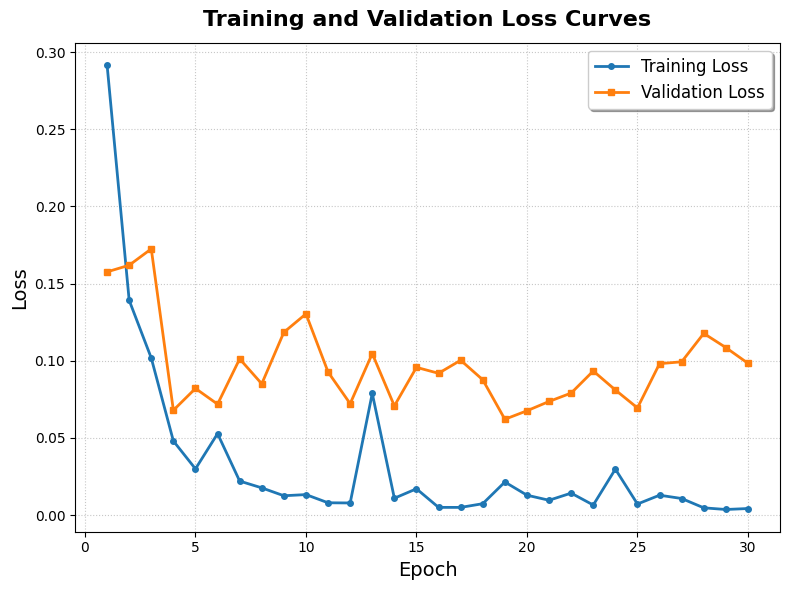

In [44]:
# 传递 save_suffix 参数（如果使用离线增强，目录名会加上"A"）
plot_curves(train_losses, val_losses, model_name=model_name, epoch=epoch, save=True, save_suffix=save_suffix)

Evaluating:   0%|          | 0/35 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 35/35 [00:13<00:00,  2.51it/s]


✅ Test Accuracy: 0.8112

📊 Classification Report:
              precision    recall  f1-score   support

      benign       0.87      0.47      0.61       175
   malignant       0.80      0.97      0.88       381

    accuracy                           0.81       556
   macro avg       0.84      0.72      0.74       556
weighted avg       0.82      0.81      0.79       556

✅ Saved classification report to ./New_DenseNet201_PT_FT_30/classification_report.txt
✅ Saved confusion matrix to ./New_DenseNet201_PT_FT_30/confusion_matrix.pdf


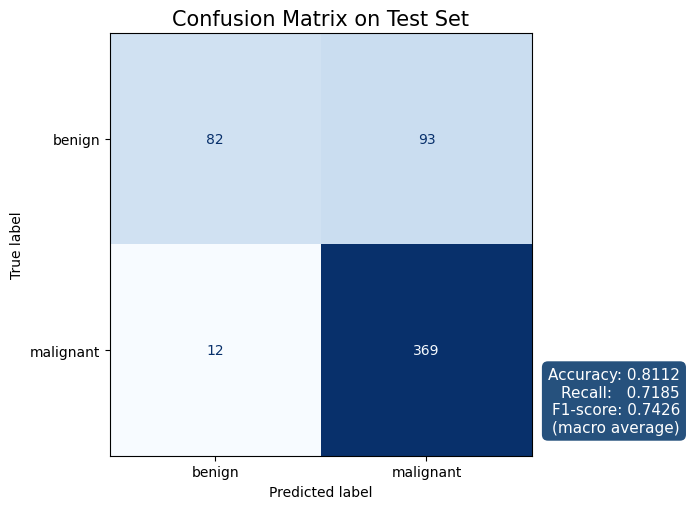

In [45]:
# 传递 save_suffix 参数（如果使用离线增强，目录名会加上"A"）
evaluate_on_testset(model, test_loader, test_ds, model_name=model_name, epoch=epoch, save=True, save_suffix=save_suffix)

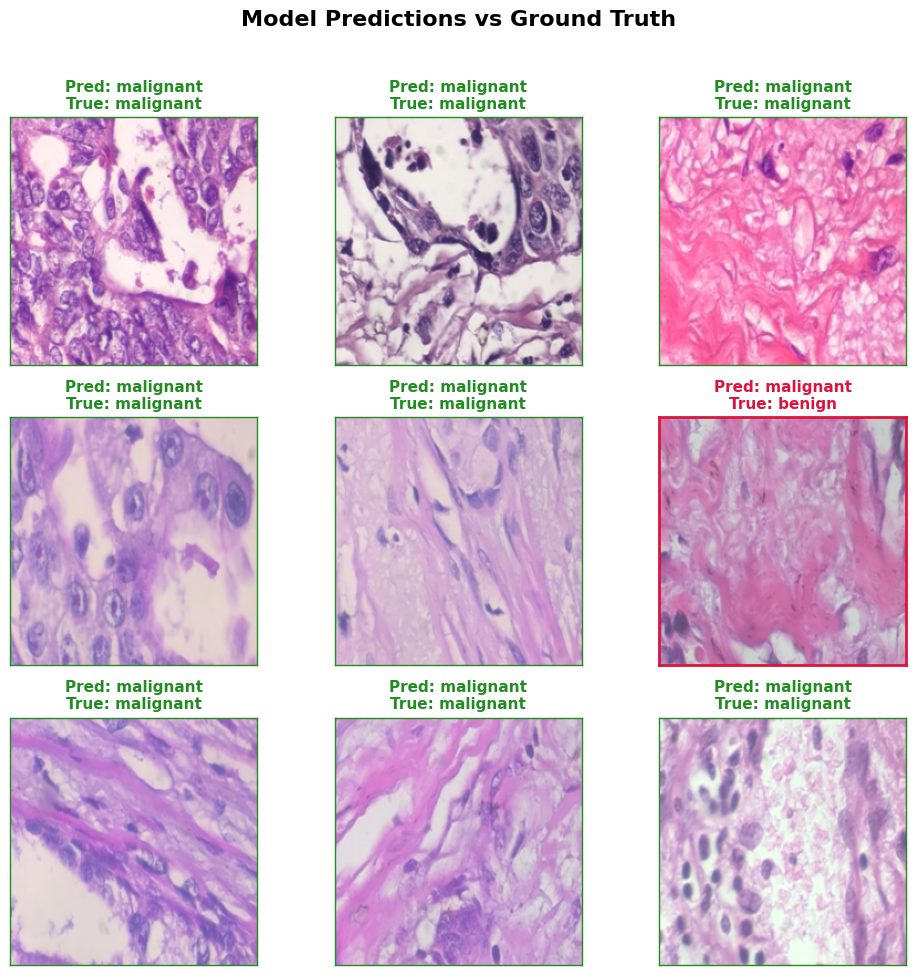

In [46]:
visualize_predictions(model, test_ds, num_images=9, mean=mean_used, std=std_used)

In [47]:
def get_last_conv_name(model):
    for name, module in reversed(list(model.named_modules())):
        if isinstance(module, torch.nn.Conv2d):
            return name
target_layer = get_last_conv_name(model)
print("Last conv layer:", target_layer)
gradcam = GradCAM(model, target_layer=target_layer)

Last conv layer: model.features.denseblock4.denselayer32.conv2


/opt/anaconda3/envs/dl/lib/python3.10/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


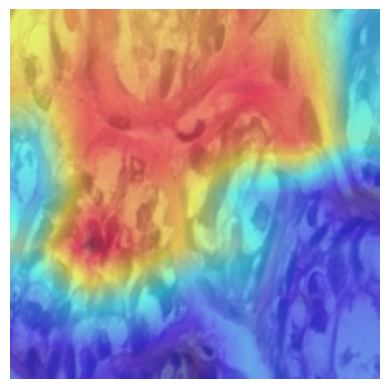

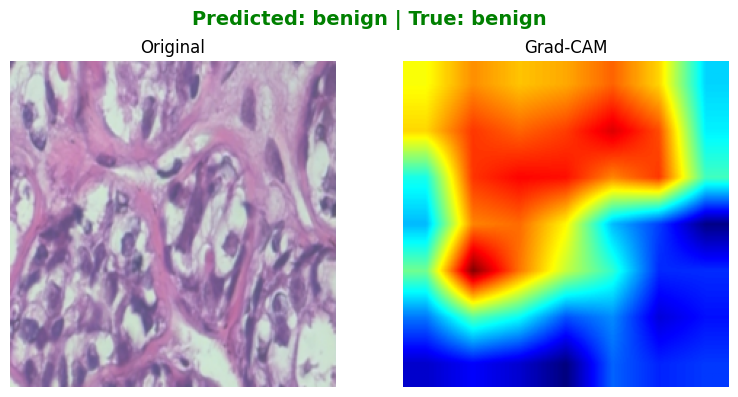

In [48]:
idx = np.random.randint(len(test_ds))
img, label_true = test_ds[idx]
cam = gradcam.generate(img.unsqueeze(0).to(device))
show_gradcam(img, cam, mean=mean_used, std=std_used)
show_gradcam_side_by_side(img, cam, model, test_ds, label_true, mean=mean_used, std=std_used)